# EVEREST: analysis of death and ascent.
## 1. Annotation
In this project I chose to work on two connected datasets from kaggle. They collect data about **Mount Everest Climbing Deaths** since 1922  with 310  recorded deaths and   **Ascent data(1953-2020)** with 10184 recorded ascents. Collaborating 2 tables together provides an opportunity not only see the picture of ordinary people who climbed the mountain, but also what are the most common causes of death and how age and oxygen consumption are related to the outcome of the expedition.

This data is courtesy of The Himalayan Database- https://www.himalayandatabase.com/index.html


# 2.Dataset description
## Dataset Mount Everest Ascent Data (1953-2020)

1. This dataset contains **10184** rows and 11 columns
2. Tha data type of all columns is mostly str and a little bit int
3. The columns in dataset are:
- PEAK ID- This is a unique identifier for the mountain
- Name - Name of the climber
- Yr/Seas - Year and Season of the ascent
- Date
- Time
- Citizenship
- Sex
- Age
- Oxygen - Ascent with/without Oxygen
- Dth- Did the ascent result in death?
- Host- Country

## Dataset Mount Everest Climbing Deaths since 1920
1. This dataset contains **310** rows and 8 columns
2. Tha data type of all columns is mostly str and a little bit int and float
3. The columns in dataset are:
- No.
- Name
- Date
- Age
- Expedition
- Nationality
- Cause of death
- Location

## Data quality
- Age in the death dataset contains gaps (NaN) – especially for early records from the 1920s
- Time in the ascent dataset contains gaps (NaN)
- Dth in the ascent dataset uses "." instead of "N" – needs to be standardized
- Yr/Seas stores year and season in one column – let's split it into two separate fields





In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import axvline, scatter
from prompt_toolkit.shortcuts import set_title

data1 = pd.read_csv("/Users/maya/Downloads/Mt_Everest_Ascent_Data.csv")
data2 = pd.read_csv("/Users/maya/Downloads/mount_everest_deaths.csv")

print("ASCENT")
print(f" first 5 rows \n {data1.head()} \n \n ")
print("Death")
print(f" first 5 rows \n {data2.head()} ")



ASCENT
 first 5 rows 
   Peak                     Name   Yr/Seas    Date   Time  Citizenship  Sex   \
0  EVER          Tenzing Norgay   1953 Spr  29-May  11:30        India    M   
1  EVER  Edmund Percival Hillary  1953 Spr  29-May  11:30  New Zealand    M   
2  EVER          Juerg P. Marmet  1956 Spr  23-May  14:00  Switzerland    M   
3  EVER            Ernst Schmied  1956 Spr  23-May  14:00  Switzerland    M   
4  EVER       Adolf (Dolf) Reist  1956 Spr  24-May  11:00  Switzerland    M   

   Age  Oxy  Dth   Host   
0    39    Y    .  Nepal  
1    33    Y    .  Nepal  
2    28    Y    .  Nepal  
3    31    Y    .  Nepal  
4    35    Y    .  Nepal   
 
 
Death
 first 5 rows 
    No.    Name          Date  Age                             Expedition  \
0    1   Dorje  June 7, 1922  NaN  1922 British Mount Everest Expedition   
1    2  Lhakpa  June 7, 1922  NaN  1922 British Mount Everest Expedition   
2    3   Norbu  June 7, 1922  NaN  1922 British Mount Everest Expedition   
3    4  P

In [62]:
#sizes of datasets

print("ASCENT")
print(f"1. Column's names: {data1.columns}")
print(f"2. There are {data1.shape[0]} columns and {data1.shape[1]} rows \n \n")
print("Death")
print(f"1. Column's names: {data2.columns}")
print(f"2. There are {data2.shape[0]} columns and {data2.shape[1]} rows \n \n")

ASCENT
1. Column's names: Index(['Peak ', 'Name ', 'Yr/Seas ', 'Date ', 'Time ', 'Citizenship ', 'Sex ',
       'Age ', 'Oxy ', 'Dth ', 'Host '],
      dtype='str')
2. There are 10184 columns and 11 rows 
 

Death
1. Column's names: Index(['No.', 'Name', 'Date', 'Age', 'Expedition', 'Nationality',
       'Cause of death', 'Location'],
      dtype='str')
2. There are 310 columns and 8 rows 
 



In [63]:
#datatypes
print("ASCENT")
print(data1.info())
print("\n \n")

print('Death')
print(data2.info())


ASCENT
<class 'pandas.DataFrame'>
RangeIndex: 10184 entries, 0 to 10183
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Peak          10184 non-null  str  
 1   Name          10184 non-null  str  
 2   Yr/Seas       10184 non-null  str  
 3   Date          10184 non-null  str  
 4   Time          8541 non-null   str  
 5   Citizenship   10184 non-null  str  
 6   Sex           10184 non-null  str  
 7   Age           10184 non-null  int64
 8   Oxy           10184 non-null  str  
 9   Dth           10184 non-null  str  
 10  Host          10184 non-null  str  
dtypes: int64(1), str(10)
memory usage: 1.5 MB
None

 

Death
<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   No.             310 non-null    int64  
 1   Name            310 non-null    str    
 2   Date            310 no

In [64]:
#missing info
print("ASCENT")
print(data1.isnull().sum())
print("\n \n")
print('Death')
print(data2.isnull().sum())


ASCENT
Peak               0
Name               0
Yr/Seas            0
Date               0
Time            1643
Citizenship        0
Sex                0
Age                0
Oxy                0
Dth                0
Host               0
dtype: int64

 

Death
No.                 0
Name                0
Date                0
Age               150
Expedition         39
Nationality         1
Cause of death     14
Location           19
dtype: int64


# Descriptive statistics


In [65]:
# Remove NBSP from the column names of the ascent dataset
data1.columns = data1.columns.str.strip()
print("Columns after cleaning:", data1.columns.tolist())


Columns after cleaning: ['Peak', 'Name', 'Yr/Seas', 'Date', 'Time', 'Citizenship', 'Sex', 'Age', 'Oxy', 'Dth', 'Host']


In [66]:
# Ascent
print("ASCENT\n")
print("Age of alpinists")
mean_age = data1.Age.mean()
print(f"Mean age of alpinists: {mean_age:.3f} year")
median_age = data1.Age.median()
print(f"Median age of alpinists: {median_age:.3f} year")
deviation = data1["Age"].std()
print(f"Standard deviation of alpinists: {deviation:.3f} year")
maxx = data1["Age"].max()
print(f"Max age of alpinists: {maxx:.0f} year")
minn = data1.Age.min()
print(f"Min age of alpinists: {minn:.0f}")
nulls = data1["Age"].isnull().sum()
print(f"Null age of alpinists: {nulls:.0f}")
print("\n \n")
# Death
print("Death\n")
print("Age of alpinists")
mean_age = data2.Age.mean()
print(f"Mean age of alpinists: {mean_age:.3f} year")
median_age = data2.Age.median()
print(f"Median age of alpinists: {median_age:.3f} year")
deviation = data2["Age"].std()
print(f"Standard deviation of alpinists: {deviation:.3f} year")
maxx = data2["Age"].max()
print(f"Max age of alpinists: {maxx:.0f} year")
minn = data2.Age.min()
print(f"Min age of alpinists: {minn:.0f}")
nulls = data2["Age"].isnull().sum()
print(f"Null age of alpinists: {nulls:.0f}")



ASCENT

Age of alpinists
Mean age of alpinists: 34.691 year
Median age of alpinists: 34.000 year
Standard deviation of alpinists: 10.305 year
Max age of alpinists: 80 year
Min age of alpinists: 0
Null age of alpinists: 0

 

Death

Age of alpinists
Mean age of alpinists: 40.356 year
Median age of alpinists: 38.000 year
Standard deviation of alpinists: 12.245 year
Max age of alpinists: 85 year
Min age of alpinists: 19
Null age of alpinists: 150


In [67]:
#transfer name Y and N from column oxygen from 1st dataset to describe it
data1["Oxy_num"] = data1["Oxy"].map({"Y" : 1, "No" : 0})


In [68]:
print("ASCENT \nUse of oxygen \n")

print("Usage of oxygen during ascending")
mean_ox = data1["Oxy_num"].mean()
print(f"Mean oxygen use by alpinists: {mean_ox*100:.3f} %")
median_ox = data1["Oxy_num"].median()
print(f"Median oxygen use by alpinists: {median_ox*100:.3f} %")
deviation = data1["Oxy_num"].std()
print(f"Standard deviation of oxygen use: {deviation*100:.3f} %")
nulls = data1["Oxy_num"].isnull().sum()
print(f"Null oxygen use by alpinists: {nulls:.0f}")


ASCENT 
Use of oxygen 

Usage of oxygen during ascending
Mean oxygen use by alpinists: 97.879 %
Median oxygen use by alpinists: 100.000 %
Standard deviation of oxygen use: 14.409 %
Null oxygen use by alpinists: 0


In [69]:
#transfer names in column Death into numerical type

data1['Dth_num'] = data1['Dth'].map({"Y": 1, '.' : 0})

data1['Dth_num']

0        0
1        0
2        0
3        0
4        0
        ..
10179    0
10180    0
10181    0
10182    0
10183    0
Name: Dth_num, Length: 10184, dtype: int64

In [70]:
print("ASCENT \nUse of oxygen \n")

print("Death during ascending")


mean_d = data1["Dth_num"].mean()
print(f"Mean death of alpinists: {mean_d*100:.1f} %")

median_d = data1["Dth_num"].median()
print(f"Median death of alpinists: {median_d:.0f}")

std_d = data1["Dth_num"].std()
print(f"Standard deviation of death: {std_d:.3f}")

nulls_d = data1["Dth_num"].isnull().sum()
print(f"Null death of alpinists: {nulls_d}")

print(f"\nTotal deaths: {(data1['Dth_num'] == 1).sum()}")

ASCENT 
Use of oxygen 

Death during ascending
Mean death of alpinists: 0.8 %
Median death of alpinists: 0
Standard deviation of death: 0.090
Null death of alpinists: 0

Total deaths: 83


In [71]:
data1.describe()


,Age,Oxy_num,Dth_num
count,10184.000000,10184.00000,10184.000000
mean,34.690888,0.97879,0.008150
std,10.304911,0.14409,0.089913
min,0.000000,0.00000,0.000000
25%,28.000000,1.00000,0.000000
50%,34.000000,1.00000,0.000000
75%,41.000000,1.00000,0.000000
max,80.000000,1.00000,1.000000


In [72]:
data2.describe()

,No.,Age
count,310.000000,160.000000
mean,155.500000,40.356250
std,89.633513,12.244545
min,1.000000,19.000000
25%,78.250000,31.750000
50%,155.500000,38.000000
75%,232.750000,48.000000
max,310.000000,85.000000


# Data cleanup
1. Convert the `Dth` and `Oxy` columns of the ascent dataset into numerical 0/1 flags (`Dth_num`, `Oxy_num`)
2. Split `Yr/Seas` into a separate numeric `Year` column (and keep the season string).
3. Drop the `Peak` column, since it is constant (every row is "Everest") and carries no information.
4. Convert `Sex` into a numeric flag `Sex_num` (1 = male, 0 = female).
5. Drop rows with missing `Time` in the ascent dataset.
6. In the deaths dataset, extract the `Year` from the `Date` string, drop rows where this fails, and drop rows with missing `Age`, `Expedition`, `Nationality`, `Cause of death`, or `Location`.

In [73]:
#cleaning the 1st dataset

#1. transfer names in column Death into numerical type

data1['Dth_num'] = data1['Dth'].map({"Y": 1, '.' : 0})

data1['Dth_num']


0        0
1        0
2        0
3        0
4        0
        ..
10179    0
10180    0
10181    0
10182    0
10183    0
Name: Dth_num, Length: 10184, dtype: int64

In [74]:
#2. transfer name Y and N from column oxygen from 1st dataset to describe it
data1["Oxy_num"] = data1["Oxy"].map({"Y" : 1, "No" : 0})

In [75]:
# проверка что все перенеслось
print(data1[['Dth', 'Dth_num', 'Oxy', 'Oxy_num']].head())

  Dth  Dth_num Oxy  Oxy_num
0   .        0   Y        1
1   .        0   Y        1
2   .        0   Y        1
3   .        0   Y        1
4   .        0   Y        1


In [76]:
#3. split Yr/Seas column
data1.columns = data1.columns.str.strip()
data1["Year"] = data1["Yr/Seas"].str.extract(r"(\d{4})").astype(int)
data1["Date"] = data1["Date"].str.strip()

In [77]:
#4.delete column Peak
data1 = data1.drop(columns=["Peak"])

In [78]:
#5. transfer name M and F from column sex from 1st dataset into 1 and 0
data1["Sex_num"] = data1["Sex"].map({"M": 1, "F": 0})
print(data1[["Sex", "Sex_num"]].head())

  Sex  Sex_num
0   M        1
1   M        1
2   M        1
3   M        1
4   M        1


In [79]:
#the amount of Nan rows
data1.isna().sum()

Name              0
Yr/Seas           0
Date              0
Time           1643
Citizenship       0
Sex               0
Age               0
Oxy               0
Dth               0
Host              0
Oxy_num           0
Dth_num           0
Year              0
Sex_num           0
dtype: int64

In [80]:
#6. delete rows with Nan

a = len(data1)
print(f"rows before delete {len(data1)}")
data1 = data1.dropna(subset=["Time"])
print(f"Was deleted {a - len(data1)} rowR")

rows before delete 10184
Was deleted 1643 rowR


In [81]:
#cleaning 2nd dataset
#1. delete column No.
data2=data2.drop(columns=["No."])

In [82]:
# 2 separate column Date
data2['Year'] = data2['Date'].str.extract(r'(\d{4})')
data2 = data2.dropna(subset=['Year'])
data2['Year'] = data2['Year'].astype(int)
print(data2[['Date', 'Year']].head())

           Date  Year
0  June 7, 1922  1922
1  June 7, 1922  1922
2  June 7, 1922  1922
3  June 7, 1922  1922
4  June 7, 1922  1922


In [83]:
#6. delete rows with Nan

data2 = data2.dropna(subset=["Age"])
data2 = data2.dropna(subset=["Expedition"])
data2 = data2.dropna(subset=["Cause of death"])
data2 = data2.dropna(subset=["Location"])
data2 = data2.dropna(subset=["Nationality"])
data2.isna().sum()


Name              0
Date              0
Age               0
Expedition        0
Nationality       0
Cause of death    0
Location          0
Year              0
dtype: int64

# Plots


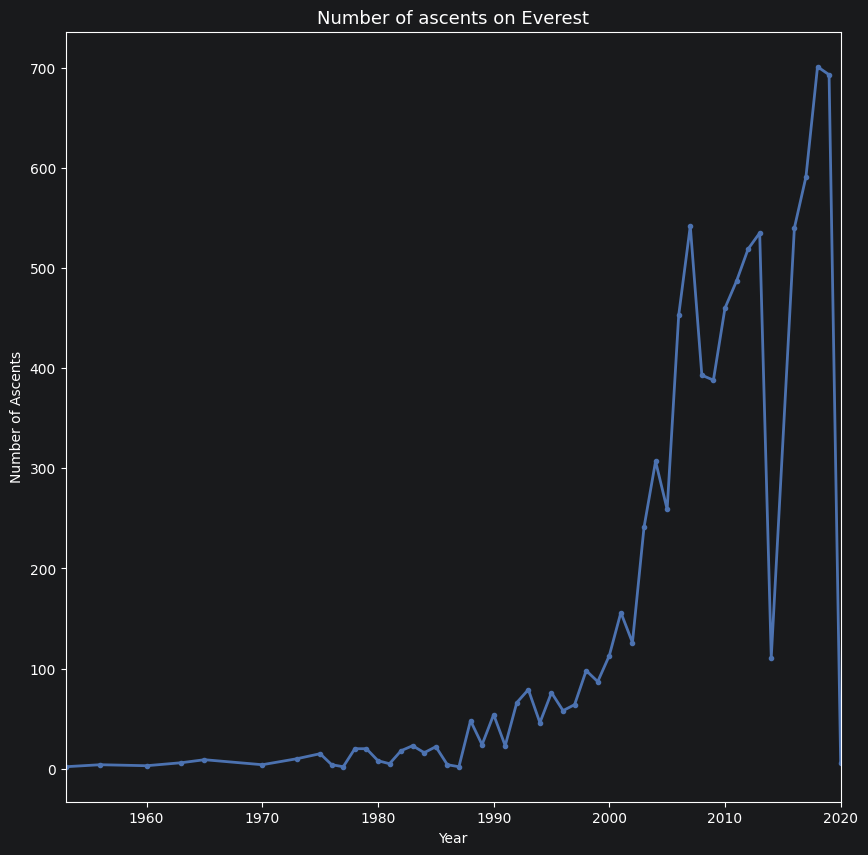

In [85]:
##simple line plot for ascending
ascents_year=data1.groupby('Year').size().reset_index(name='Ascents')
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(ascents_year["Year"], ascents_year["Ascents"], color='#4C72B0', linewidth=2, marker='o', markersize=3 )
ax.set_title("Number of ascents on Everest", fontsize =13)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Ascents")
ax.set_xlim(1953, 2020)
plt.show()

The number of ascents per year generally witnessed an upward trend from 1960. moreover, we can observe striking fluctuations during the whole period of time.

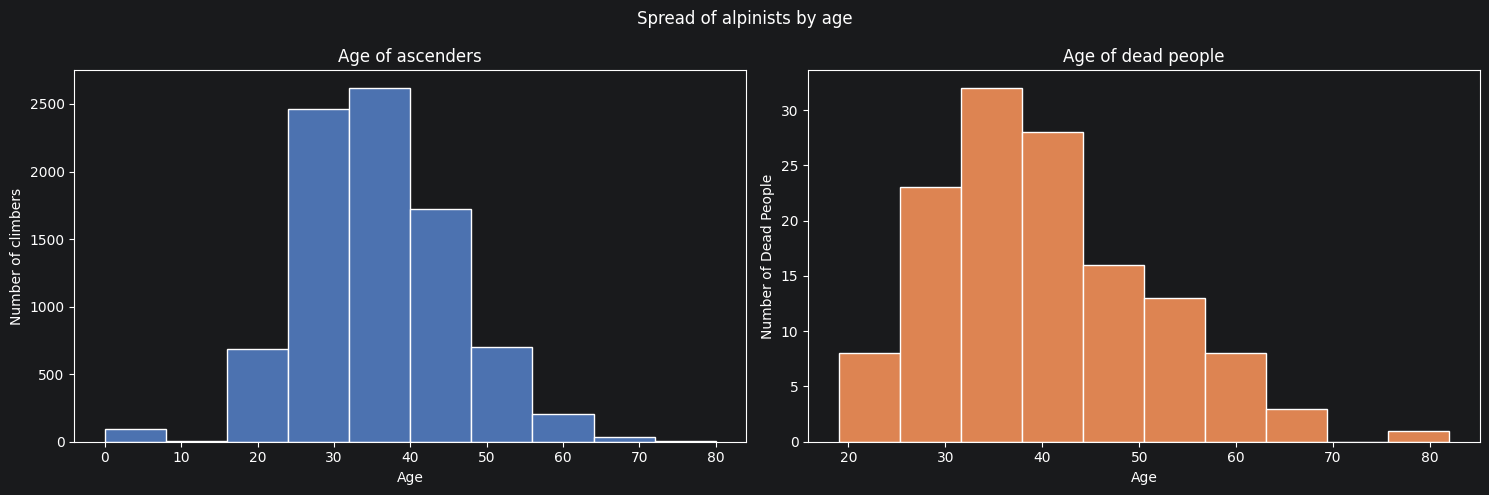

In [86]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Spread of alpinists by age')
axes[0].hist(data1["Age"], bins = 10, color='#4C72B0', edgecolor='white')
axes[0].set_title("Age of ascenders")
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of climbers')


axes[1].hist(data2["Age"], bins = 10, color='#DD8452', edgecolor='white')
axes[1].set_title("Age of dead people")
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Dead People')

plt.tight_layout()
plt.show()



Both distributions are centred around 30-40 years old.

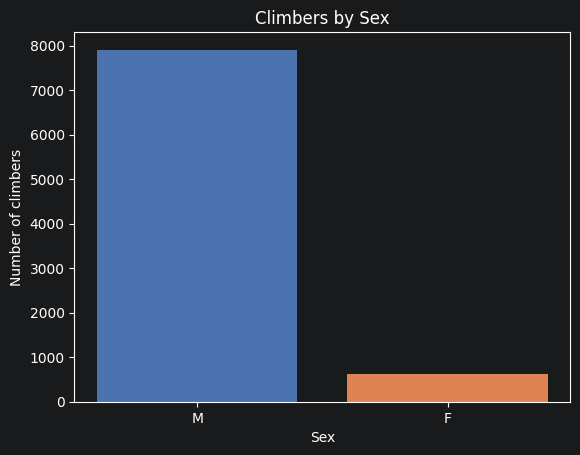

In [87]:
# Столбчатая диаграмма: число восходителей по полу

sex_counts = data1["Sex"].value_counts()


fig, ax = plt.subplots()

ax.bar(
    sex_counts.index,
    sex_counts.values,
    color=['#4C72B0', '#DD8452']
)

ax.set_title("Climbers by Sex")
ax.set_ylabel("Number of climbers")
ax.set_xlabel("Sex")
plt.show()

The bar chart confirms that Everest climbers are overwhelmingly male.

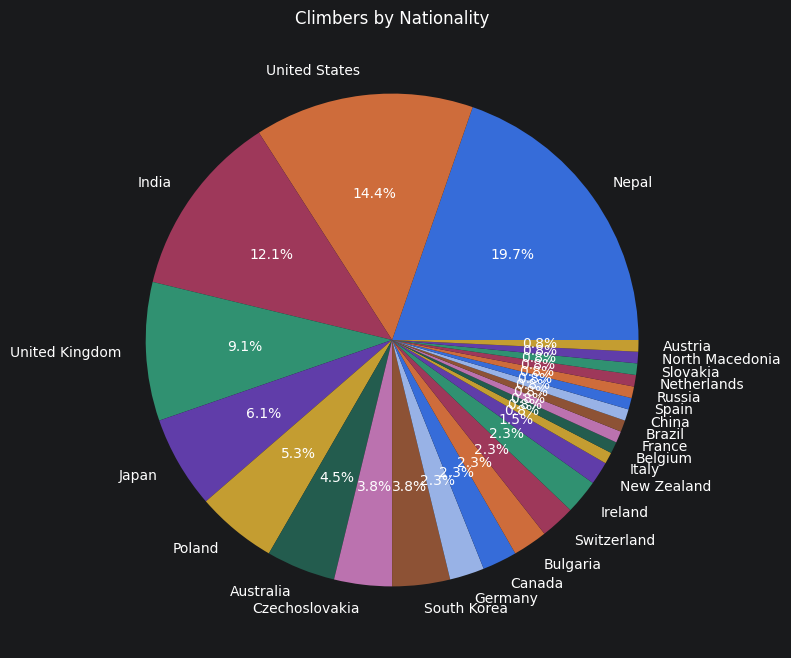

In [88]:
# круговая диаграмма по национальности погибших
nationality_count = data2['Nationality'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(
    nationality_count.values,
     labels=nationality_count.index,
    autopct="%1.1f%%"
)
plt.title("Climbers by Nationality")
plt.show()


Nepali climbers made up the largest single group among recorded fatalities, followed by American and Indian climbers

## 6. Detailed overview

I present here a comparison of top countries by ascents vs. top causes of death, a histogram comparison of age distributions on the same figure, a side-by-side comparison of ascents vs. deaths by decade with a derived mortality rate, and a time-series comparison of oxygen vs. non-oxygen ascents.

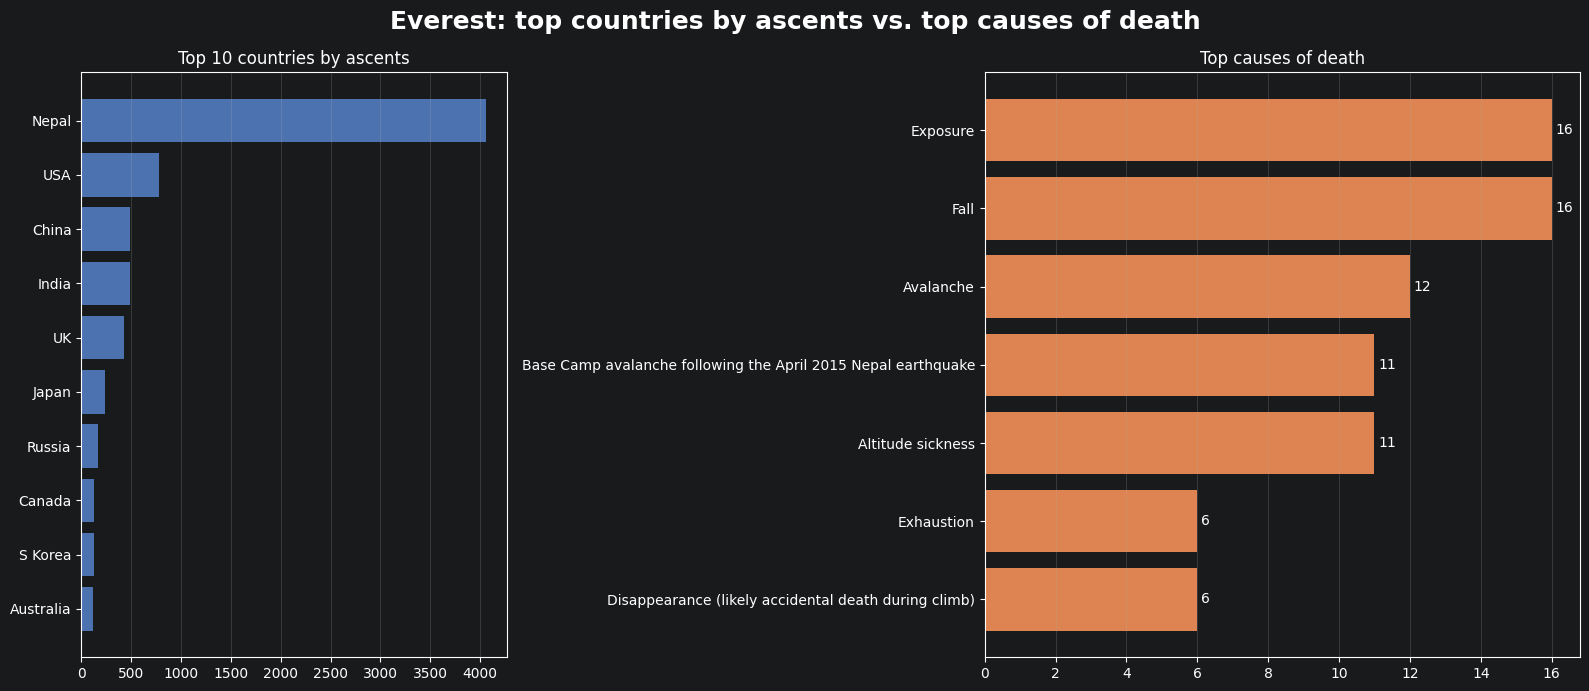

In [89]:
# Сравнение: топ-10 стран по числу восхождений vs топ причин смерти
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7),
    gridspec_kw={'width_ratios': [1, 1.4]}
)

fig.suptitle(
    'Everest: top countries by ascents vs. top causes of death',
    fontsize=18,
    fontweight='bold'
)

# 1st Top countries by ascents
top_countries = (
    data1['Citizenship']
    .value_counts()
    .head(10)
    .sort_values()
)

axes[0].barh(
    top_countries.index,
    top_countries.values,
    color='#4C72B0'
)

axes[0].set_title('Top 10 countries by ascents')
axes[0].grid(axis='x', alpha=0.3)


# Causes of death
death_causes = (
    data2['Cause of death']
    .value_counts()
    .head(7)
    .sort_values()
)

bars = axes[1].barh(
    death_causes.index,
    death_causes.values,
    color='#DD8452'
)

axes[1].set_title('Top causes of death')
axes[1].grid(axis='x', alpha=0.3)

for bar in bars:
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                  str(int(bar.get_width())), va='center')

plt.tight_layout()
plt.show()

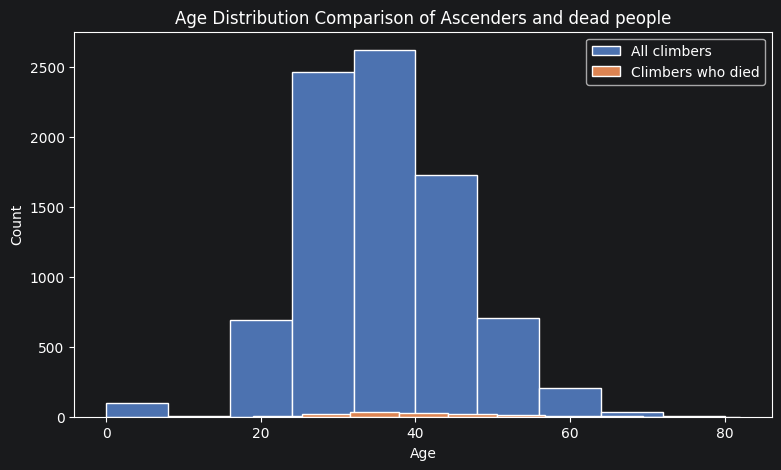

In [90]:
#Сравнение распределений возраста на одном графике (overlay histograms)

# возраст из 2 датасета
age2 = data2["Age"].dropna()

# возраст из 1 датасета
age1 = data1["Age"].dropna()

plt.figure(figsize=(9,5))

plt.hist(age1, bins=10, alpha=1, label="All climbers", color="#4C72B0", edgecolor='white')
plt.hist(age2, bins=10, alpha=1, label="Climbers who died", color="#DD8452", edgecolor='white')

plt.title("Age Distribution Comparison of Ascenders and dead people")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()

plt.show()

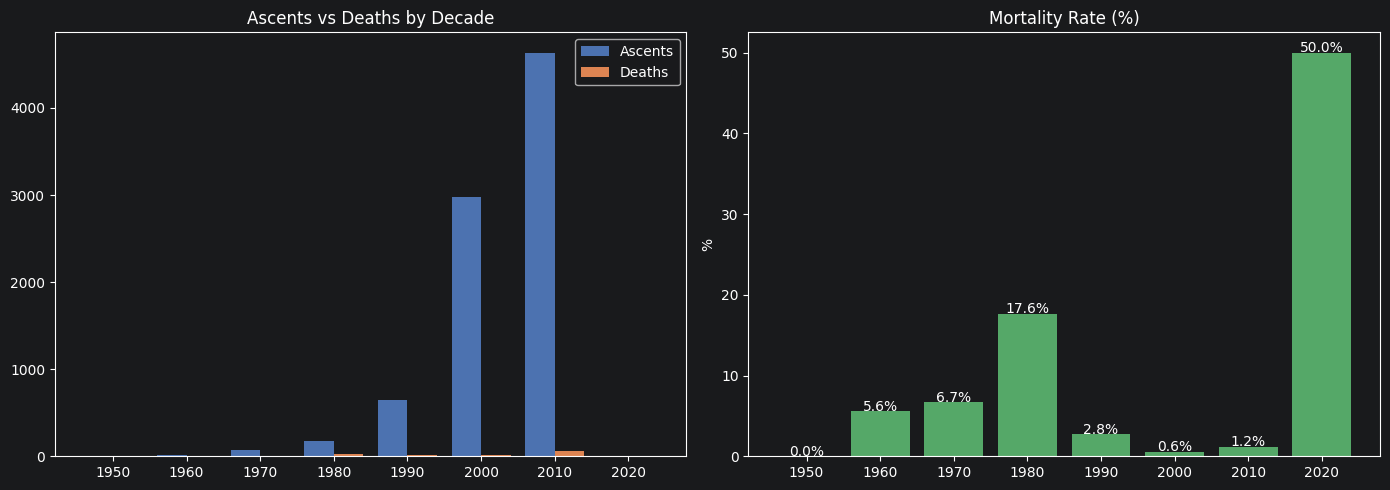


Mortality by decade (%):
Decade
1950     0.00
1960     5.56
1970     6.67
1980    17.65
1990     2.76
2000     0.57
2010     1.19
2020    50.00
dtype: float64


In [91]:
# Сравнение по десятилетиям: число восхождений vs число смертей, и уровень смертности


# десятилетия
data1['Decade'] = (data1['Year'] // 10) * 10
data2['Decade'] = (data2['Year'] // 10) * 10

# только после первого успешного восхождения
asc_decade = (
    data1[data1['Year'] >= 1953]
    .groupby('Decade')
    .size()
)

dth_decade = (
    data2[data2['Year'] >= 1953]
    .groupby('Decade')
    .size()
)


decades = sorted(set(asc_decade.index) | set(dth_decade.index))

asc_plot = asc_decade.reindex(decades, fill_value=0)
dth_plot = dth_decade.reindex(decades, fill_value=0)

# смертность
mortality = (dth_plot / asc_plot * 100)
mortality = mortality.replace([np.inf, -np.inf], np.nan).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1
x = np.arange(len(decades))

axes[0].bar(
    x - 0.2,
    asc_plot.values,
    width=0.4,
    label='Ascents',
    color='#4C72B0'
)

axes[0].bar(
    x + 0.2,
    dth_plot.values,
    width=0.4,
    label='Deaths',
    color='#DD8452'
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(decades)

axes[0].set_title('Ascents vs Deaths by Decade')
axes[0].legend()

# 2

axes[1].bar(
    x,
    mortality.values,
    color='#55A868'
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(decades)

axes[1].set_title('Mortality Rate (%)')
axes[1].set_ylabel('%')

for i, v in enumerate(mortality.values):
    axes[1].text(i, v + 0.05, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

print("\nMortality by decade (%):")
print(mortality.round(2))

The left graph shows that both ascents and (in absolute numbers) deaths increased over time, simply because far more people attempt the mountain in recent decades. The right panel normalises this by computing a mortality *rate* (deaths divided by ascents), which shows whether the mountain has become relatively safer or more dangerous per climbers

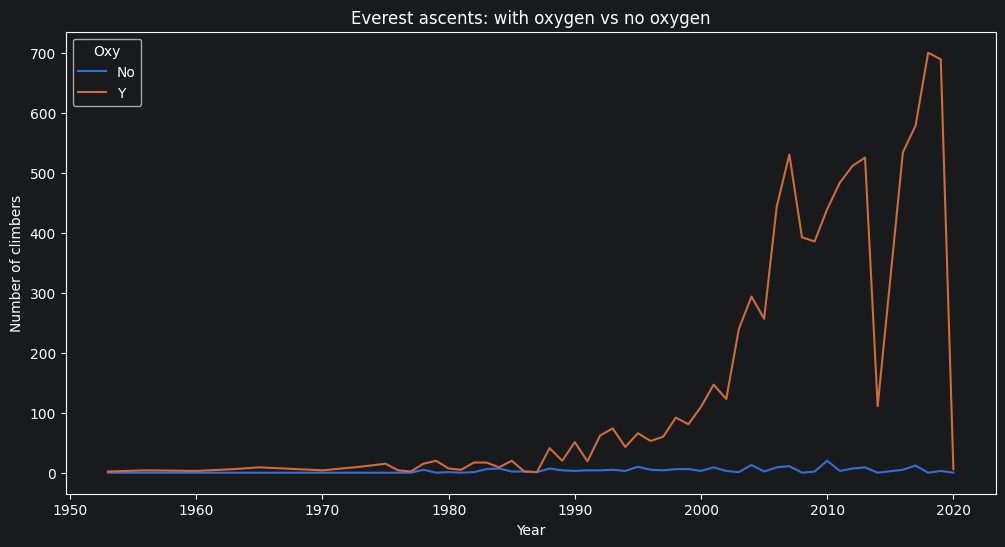

In [92]:


oxy_year = data1.groupby(['Year', 'Oxy']).size().unstack(fill_value=0)

oxy_year.plot(figsize=(12,6))

plt.title('Everest ascents: with oxygen vs no oxygen')
plt.xlabel('Year')
plt.ylabel('Number of climbers')
plt.show()


Ascents using supplemental oxygen ("Y") consistently outnumber ascents without it ("No") across most years, reflecting the dominance of commercial, oxygen-assisted expeditions.However, ascents without oxygen was the same popular as without before 1975, it could happened bacause of lack of special equipment in that decades.

## 7. Data transformation
Before, I created new columns because of the need to separate data with string types for further analysis. Through the project I admitted that having age groups will be more convenient for data description.
I created an **age group** column (`AgeGroup`) by binning `Age` into categories. This makes it possible to compare oxygen use and mortality across age brackets directly.

In [93]:
bins = [0, 25, 35, 45, 55, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55+']
data1['AgeGroup'] = pd.cut(data1['Age'], bins=bins, labels=labels, right=False)
data2['AgeGroup'] = pd.cut(data2['Age'], bins=bins, labels=labels, right=False)
print(data1[['Age', 'AgeGroup']].head())
print(data1['AgeGroup'].value_counts().sort_index())

   Age AgeGroup
0   39    35-44
1   33    25-34
2   28    25-34
3   31    25-34
4   35    35-44
AgeGroup
<25      1032
25-34    3285
35-44    2756
45-54    1163
55+       305
Name: count, dtype: int64


## 8. Hypothesis check
- **1st Hypothesis** Older climbers benefit more from supplemental oxygen in terms of mortality reduction than younger climbers.

- **2nd Hypothesis** Younger climbers are more likely to die from external mountain hazards, while older climbers are more vulnerable to internal physiological stress.

- **3rd Hypothesis**  Younger climbers die more from external hazards, older climbers from physiological causes
- **4th Hypothesis** Ascents from Nepal side have higher mortality rates and lower oxygen utilization rates than from Chinese side.



- **1st Hypothesis** Older climbers benefit more from supplemental oxygen in terms of mortality reduction than younger climbers.
Method:   mortality rates were compared between climbers who used supplemental oxygen and those who did not.

  AgeGroup      Oxygen Use  Mortality Rate (%)
0      <25  Without Oxygen                0.00
1      <25     With Oxygen                0.20
2    25-34  Without Oxygen                7.95
3    25-34     With Oxygen                0.63
4    35-44  Without Oxygen                6.10
5    35-44     With Oxygen                0.71
6    45-54  Without Oxygen                5.26
7    45-54     With Oxygen                0.96
8      55+  Without Oxygen                0.00
9      55+     With Oxygen                2.30


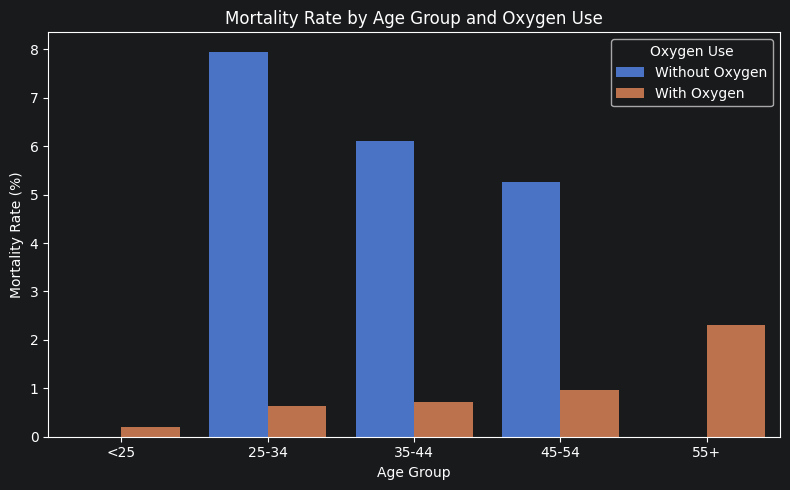

In [94]:
# Hypothesis 1:
# Calculate mortality rate
mortality = (
    data1.groupby(['AgeGroup', 'Oxy_num'])['Dth_num']
    .mean()
    .reset_index()
)

# Convert to percentages
mortality['Mortality Rate (%)'] = mortality['Dth_num'] * 100

# Replace 0/1 with readable labels
mortality['Oxygen Use'] = mortality['Oxy_num'].map({
    0: 'Without Oxygen',
    1: 'With Oxygen'
})

# Display table
result_table = mortality[
    ['AgeGroup', 'Oxygen Use', 'Mortality Rate (%)']
].round(2)

print(result_table)

# Plot
plt.figure(figsize=(8,5))

sns.barplot(
    data=mortality,
    x='AgeGroup',
    y='Mortality Rate (%)',
    hue='Oxygen Use'
)

plt.title('Mortality Rate by Age Group and Oxygen Use')
plt.xlabel('Age Group')
plt.ylabel('Mortality Rate (%)')
plt.legend(title='Oxygen Use')

plt.tight_layout()
plt.show()



# Conclusion:
Mortality rates were significantly lower for climbers using supplemental oxygen throughout the year. For climbers under the age of 55, the mortality rate dropped from 6-7% without oxygen to 1% or less with supplemental oxygen.

Oxygen deprivation mortality increased slightly with age (6.60%, 6.67%, and 7.14%), indicating that older climbers were at greater risk during the ascent. However, the reduction in mortality associated with the use of supplemental oxygen was similar across age groups. The dataset included climbers aged 55 and older using oxygen, so direct comparisons are not possible.

**2nd Hypothesis** Mortality rate on Everest has decreased over decades, while number of climbers has increased (P.S. the mountain has become relatively safer per climber despite being more crowded.)

In [101]:

import plotly.graph_objects as go

asc_decade = data1[data1['Year'] >= 1953].groupby('Decade').size()
dth_decade = data2[data2['Year'] >= 1953].groupby('Decade').size()

decades = sorted(set(asc_decade.index) | set(dth_decade.index))
asc_plot = asc_decade.reindex(decades, fill_value=0)
dth_plot = dth_decade.reindex(decades, fill_value=0)

# смерти / восхождения * 100
mortality = (dth_plot / asc_plot * 100).replace([np.inf, -np.inf], np.nan).fillna(0)

overview = pd.DataFrame({
    'Decade': decades,
    'Ascents': asc_plot.values,
    'Deaths': dth_plot.values,
    'MortalityRate_%': mortality.round(2).values
})
print(overview)


fig = go.Figure()
fig.add_trace(go.Bar(
    x=[str(d) for d in decades], y=overview['Ascents'],
    name='Ascents', marker_color='#4C8FA8', opacity=0.6, yaxis='y1'
))
fig.add_trace(go.Scatter(
    x=[str(d) for d in decades], y=overview['MortalityRate_%'],
    name='Mortality rate (%)', marker_color='#E8743B',
    mode='lines+markers', yaxis='y2', line=dict(width=3)
))
fig.update_layout(
    title='Ascents (bars) vs. Mortality rate (line) by decade',
    yaxis=dict(title='Number of ascents'),
    yaxis2=dict(title='Mortality rate (%)', overlaying='y', side='right'),
    legend=dict(orientation='h', y=1.1)
)
fig.show()


early = overview[overview['Decade'] < 1990]['MortalityRate_%'].mean()
late = overview[(overview['Decade'] >= 1990) & (overview['Decade'] < 2020)]['MortalityRate_%'].mean()
print(f"\nAvg mortality rate before 1990: {early:.2f}%")
print(f"Avg mortality rate 1990-2010s: {late:.2f}%")

   Decade  Ascents  Deaths  MortalityRate_%
0    1950        6       0             0.00
1    1960       18       1             5.56
2    1970       75       5             6.67
3    1980      170      30            17.65
4    1990      651      18             2.76
5    2000     2978      17             0.57
6    2010     4637      55             1.19
7    2020        6       3            50.00



Avg mortality rate before 1990: 7.47%
Avg mortality rate 1990-2010s: 1.51%


###  Conclusion:
 **from 1950s to the 1990s mortality rate was higher in comparison with remaining years. Moreover, percentage of deaths reached a peak in 1980 at 17.65, which was quite high for these time. Then rate dropped  to 2.76% in the 2010s, despite the highest number of ascents during that decade. The 2020 decade is not meaningfully considered—it only had 22 ascents (data is incomplete/truncated), so the jump to 22.7% is statistical noise, not a trend.**

Hypothesis 3 — Younger climbers die more from external hazards, older climbers from physiological causes

In [106]:

import plotly.graph_objects as go

def classify_cause(cause):

    if pd.isna(cause):
        return "Unknown"
    text = cause.lower()

    external_keywords = [
        "avalanche", "fall", "crevasse", "serac", "ice axe", "rope accident",
        "snowboarding", "blizzard", "snow blindness", "drown"
    ]
    physiological_keywords = [
        "exhaustion", "exposure", "altitude sickness", "hape", "hace",
        "oedema", "edema", "frostbite", "hypothermia", "heart", "cardiac",
        "stroke", "starvation"
    ]

    has_external = any(kw in text for kw in external_keywords)
    has_physio = any(kw in text for kw in physiological_keywords)

    if has_external and has_physio:
        return "Mixed"
    elif has_external:
        return "External hazard"
    elif has_physio:
        return "Physiological"
    elif "disappear" in text or "unknown" in text or "presumed dead" in text:
        return "Unknown/Disappearance"
    else:
        return "Other"

data2["CauseType"] = data2["Cause of death"].apply(classify_cause)

print("Distribution of cause types:")
print(data2["CauseType"].value_counts())


subset = data2[data2["CauseType"].isin(["External hazard", "Physiological"])]

age_stats = subset.groupby("CauseType")["Age"].agg(["mean", "median", "std", "count"])
print("\nAge statistics by cause type (External hazard vs Physiological):")
print(age_stats.round(2))

#гистограмма возрастов
fig = go.Figure()
colors = {"External hazard": "#4C8FA8", "Physiological": "#E8743B"}
for cause_type, color in colors.items():
    ages = subset[subset["CauseType"] == cause_type]["Age"]
    fig.add_trace(go.Histogram(
        x=ages, name=f"{cause_type} (n={len(ages)})",
        marker_color=color, opacity=0.55, nbinsx=10
    ))
    fig.add_vline(x=ages.mean(), line_dash="dash", line_color=color,
                   annotation_text=f"mean={ages.mean():.1f}")

fig.update_layout(
    barmode="overlay",
    title="Age distribution by cause-of-death type",
    xaxis_title="Age", yaxis_title="Count"
)
fig.show()

# Разница средних
mean_diff = age_stats.loc["Physiological","mean"] - age_stats.loc["External hazard","mean"]
print(f"\nDifference in mean age (Physiological - External hazard): {mean_diff:+.2f} years")

Distribution of cause types:
CauseType
External hazard          59
Physiological            59
Unknown/Disappearance    12
Mixed                     2
Name: count, dtype: int64

Age statistics by cause type (External hazard vs Physiological):
                  mean  median    std  count
CauseType                                   
External hazard  36.68    36.0   9.57     59
Physiological    45.71    44.0  12.43     59



Difference in mean age (Physiological - External hazard): +9.03 years


### hypothesis is proved:
1. Climbers who died from the external hazard were younger on 9 years. Mean proves it, respectfully.
2. std=12.43 vs 9.57 - that is, among those who died from exhaustion/altitude sickness/heart causes, the age range is wider: it includes both relatively young (with a predisposition or extreme load), and elderly climbers, for whom the physiological stress of altitude is especially dangerous.

### 4th Hypothesis:
Ascents from Nepal side have higher mortality rates and lower oxygen utilization rates than from Chinese side.

In [104]:
# Сравниваем непальскую и китайскую стороны горы
host_comparison = data1.groupby('Host').agg(
    MortalityRate=('Dth_num', 'mean'),
    OxygenUseRate=('Oxy_num', 'mean'),
    Ascents=('Dth_num', 'size'),
    MeanAge=('Age', 'mean')
)
host_comparison[['MortalityRate','OxygenUseRate']] *= 100
print(host_comparison.round(2))


fig = go.Figure()
fig.add_trace(go.Bar(
    x=host_comparison.index, y=host_comparison['MortalityRate'],
    name='Mortality rate (%)', marker_color='#C44E52'
))
fig.add_trace(go.Bar(
    x=host_comparison.index, y=host_comparison['OxygenUseRate'],
    name='Oxygen use rate (%)', marker_color='#4C8FA8'
))
fig.update_layout(
    title='Nepal side vs. China/Tibet side: mortality & oxygen use',
    barmode='group', yaxis_title='%'
)
fig.show()

# распределение восхождений по сторонам горы
fig2 = go.Figure(data=[go.Pie(
    labels=host_comparison.index, values=host_comparison['Ascents'],
    hole=0.5, marker_colors=['#4C8FA8', '#E8743B']
)])
fig2.update_layout(title='Share of ascents: Nepal side vs. China/Tibet side')
fig2.show()

# число восхождений с каждой стороны
side_decade = data1.groupby(['Decade','Host']).size().unstack(fill_value=0)
fig3 = go.Figure()
for host in side_decade.columns:
    fig3.add_trace(go.Scatter(
        x=side_decade.index.astype(str), y=side_decade[host],
        mode='lines+markers', name=host
    ))
fig3.update_layout(title='Ascents by decade: Nepal side vs. China/Tibet side',
                    xaxis_title='Decade', yaxis_title='Ascents')
fig3.show()

       MortalityRate  OxygenUseRate  Ascents  MeanAge
Host                                                 
China           1.13          96.77     3003    35.09
Nepal           0.69          98.18     5538    35.21


### Conclusion:
Nepal side is a little bit more dangerous(0.69 vs 1.13). Usage of oxygen is almost similar (96.77 vs 98.18). Hypothesis is not proved both sides of the mountain appear comparable in danger, despite the different reputations of the routes (the southern one is considered "more commercial," the northern one "more severe"), the fatality statistics are similar. the pie chart clearly shows that ~78% of all ascents are made from the Nepalese side